In [1]:
import numpy as np
import pandas as pd

np.random.seed(23) 

# Generate samples for class 1
mu_vec1 = np.array([0, 0, 0])
cov_mat1 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

# Create DataFrame for class 1
df = pd.DataFrame(class1_sample, columns=['feature1', 'feature2', 'feature3'])
df['target'] = 1

# Generate samples for class 2
mu_vec2 = np.array([1, 1, 1])
cov_mat2 = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

# Create DataFrame for class 2
df1 = pd.DataFrame(class2_sample, columns=['feature1', 'feature2', 'feature3'])
df1['target'] = 0

# Concatenate DataFrames instead of using append
df = pd.concat([df, df1], ignore_index=True)

# Randomly sample 40 rows from the combined DataFrame
df = df.sample(40)

In [2]:
df.head()

,feature1,feature2,feature3,target
2,-0.367548,-1.137460,-1.322148,1
34,0.177061,-0.598109,1.226512,0
14,0.420623,0.411620,-0.071324,1
11,1.968435,-0.547788,-0.679418,1
12,-2.506230,0.146960,0.606195,1


In [3]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [4]:
# Step 1 - Apply standard scaling for mean centring
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [5]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [6]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [7]:
eigen_values

array([1.3536065 , 0.94557084, 0.77774573])

In [8]:
eigen_vectors

array([[-0.53875915, -0.69363291,  0.47813384],
       [-0.65608325, -0.01057596, -0.75461442],
       [-0.52848211,  0.72025103,  0.44938304]])

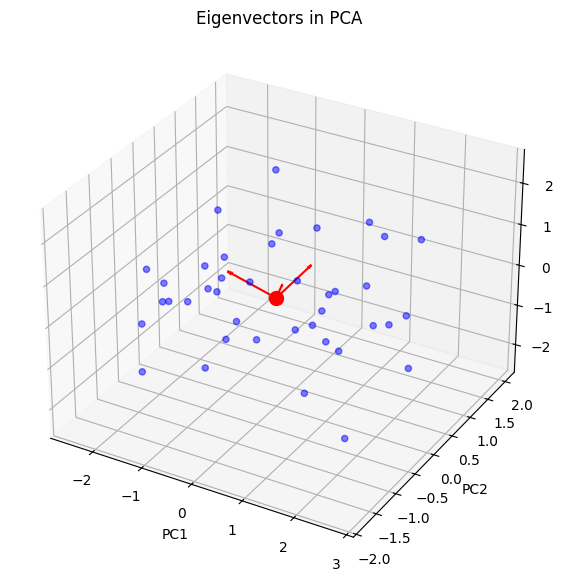

In [14]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Standardization
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

# PCA
pca = PCA(n_components=3)
principal_components = pca.fit_transform(scaled_features)
eigen_vectors = pca.components_

# 3D Visualization
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the PCA-transformed features
scatter = ax.scatter(principal_components[:, 0], principal_components[:, 1], principal_components[:, 2], 
                     color='blue', alpha=0.5)

# Mean point
mean_point = principal_components.mean(axis=0)
ax.scatter(mean_point[0], mean_point[1], mean_point[2], color='red', s=100)

# Plot eigenvectors as arrows
for vec in eigen_vectors:
    ax.quiver(mean_point[0], mean_point[1], mean_point[2], 
              vec[0], vec[1], vec[2], color='r', arrow_length_ratio=0.1)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('Eigenvectors in PCA')

plt.show()

In [19]:
pc = eigen_vectors[0:2]
pc

array([[ 0.30838125,  0.49821642,  0.49850821, -0.63888259],
       [-0.81561585, -0.19424132,  0.52861448, -0.13269448]])

In [25]:
transformed_df = principal_components[:, :2]
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,-2.487040,-0.189401,1
1,0.310974,0.771798,0
2,-0.989638,-0.457630,1
3,-1.294903,-1.666457,1
4,-1.608024,1.994160,1


In [26]:
new_df['target'] = new_df['target'].astype('str')
fig = px.scatter(x=new_df['PC1'],
                 y=new_df['PC2'],
                 color=new_df['target'],
                 color_discrete_sequence=px.colors.qualitative.G10
                )

fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))
fig.show()